/Users/javierrodriguezzaurin/.pyenv/versions/3.11.9/envs/recsys311/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


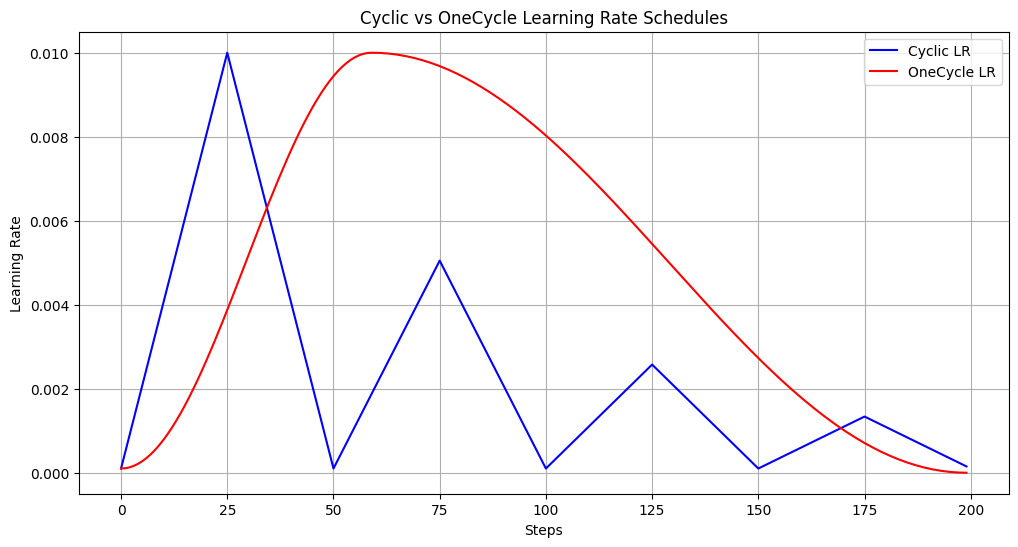

In [36]:
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import (
    CosineAnnealingLR,
    CosineAnnealingWarmRestarts,
    CyclicLR,
    OneCycleLR,
    ReduceLROnPlateau,
)
import matplotlib.pyplot as plt

model1 = torch.nn.Linear(2, 1)
model2 = torch.nn.Linear(2, 1)
optimizer1 = torch.optim.SGD(model1.parameters(), lr=1e-3)
optimizer2 = torch.optim.SGD(model2.parameters(), lr=1e-3)

scheduler1 = torch.optim.lr_scheduler.CyclicLR(
    optimizer1, base_lr=1e-4, max_lr=0.01, step_size_up=25, mode="triangular2"
)

scheduler2 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer2,
    max_lr=0.01,
    total_steps=200,
    pct_start=0.3,
    div_factor=100,
)

lrs_cyclic = []
lrs_onecycle = []

for epoch in range(200):
    lrs_cyclic.append(optimizer1.param_groups[0]["lr"])
    lrs_onecycle.append(optimizer2.param_groups[0]["lr"])
    scheduler1.step()
    scheduler2.step()

plt.figure(figsize=(12, 6))
plt.plot(lrs_cyclic, label="Cyclic LR", color="blue")
plt.plot(lrs_onecycle, label="OneCycle LR", color="red")
plt.xlabel("Steps")
plt.ylabel("Learning Rate")
plt.title("Cyclic vs OneCycle Learning Rate Schedules")
plt.legend()
plt.grid(True)
plt.show()

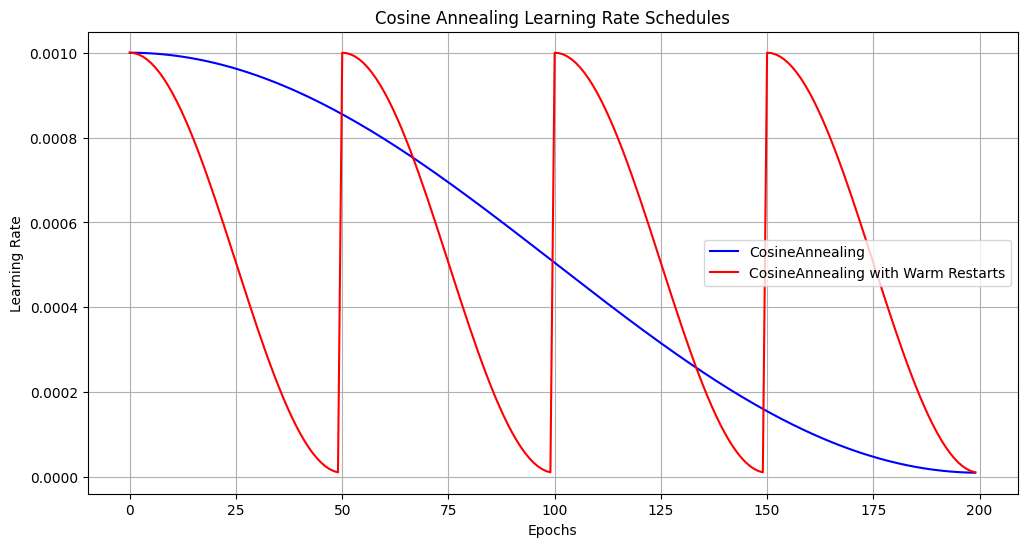

In [38]:
model1 = torch.nn.Linear(2, 1)
model2 = torch.nn.Linear(2, 1)
optimizer1 = torch.optim.SGD(model1.parameters(), lr=0.001)
optimizer2 = torch.optim.SGD(model2.parameters(), lr=0.001)

scheduler1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer1, T_max=200, eta_min=1e-5
)

scheduler2 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer2, T_0=50, T_mult=1, eta_min=1e-5
)

lrs_cosine = []
lrs_warmrestarts = []

for epoch in range(200):
    lrs_cosine.append(optimizer1.param_groups[0]["lr"])
    lrs_warmrestarts.append(optimizer2.param_groups[0]["lr"])
    scheduler1.step()
    scheduler2.step()

plt.figure(figsize=(12, 6))
plt.plot(lrs_cosine, label="CosineAnnealing", color="blue")
plt.plot(lrs_warmrestarts, label="CosineAnnealing with Warm Restarts", color="red")
plt.xlabel("Epochs")
plt.ylabel("Learning Rate")
plt.title("Cosine Annealing Learning Rate Schedules")
plt.legend()
plt.grid(True)
plt.show()

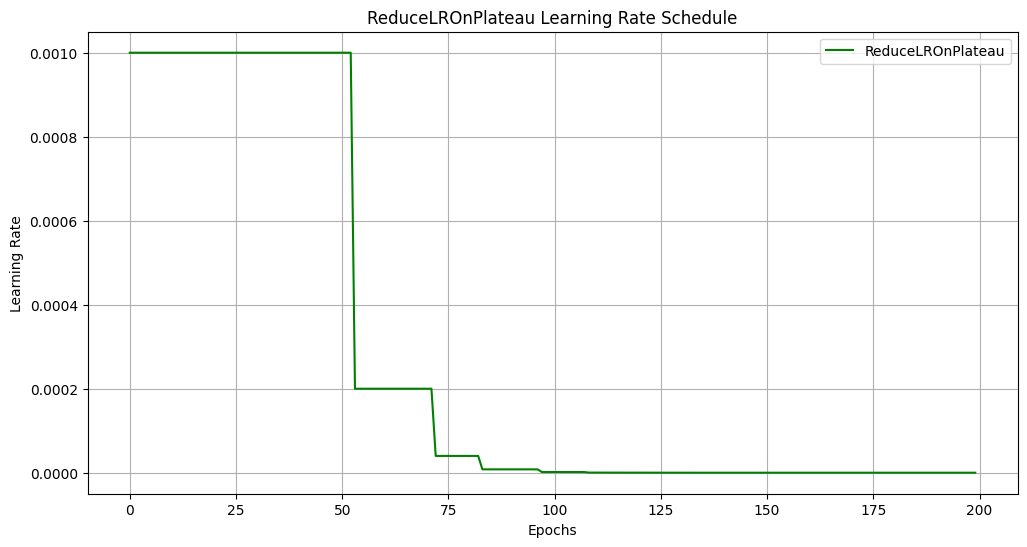

In [40]:
model = torch.nn.Linear(2, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.2, patience=10, verbose=False, threshold_mode="abs"
)

lrs_plateau = []


# Simulate loss values
def simulate_loss(epoch):
    base_loss = 1.0 / (1 + 0.1 * epoch)
    noise = 0.05 * torch.randn(1).item()
    return max(0.01, base_loss + noise)


# Training loop
for epoch in range(200):
    loss = simulate_loss(epoch)
    lrs_plateau.append(optimizer.param_groups[0]["lr"])
    scheduler.step(loss)

plt.figure(figsize=(12, 6))
plt.plot(lrs_plateau, label="ReduceLROnPlateau", color="green")
plt.xlabel("Epochs")
plt.ylabel("Learning Rate")
plt.title("ReduceLROnPlateau Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.show()